In [56]:
import numpy as np
import pandas as pd

In [57]:
import dagshub

dagshub.init(repo_owner='lbegi23', repo_name='House-Prices', mlflow=True)

Initialized MLflow to track repo "lbegi23/House-Prices"

Repository lbegi23/House-Prices initialized!

In [58]:
import mlflow

print(mlflow.get_tracking_uri())

https://dagshub.com/lbegi23/House-Prices.mlflow


# Exploratory Data Analysis (EDA)

In [59]:
df = pd.read_csv('./data/train.csv')

In [60]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [61]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [62]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

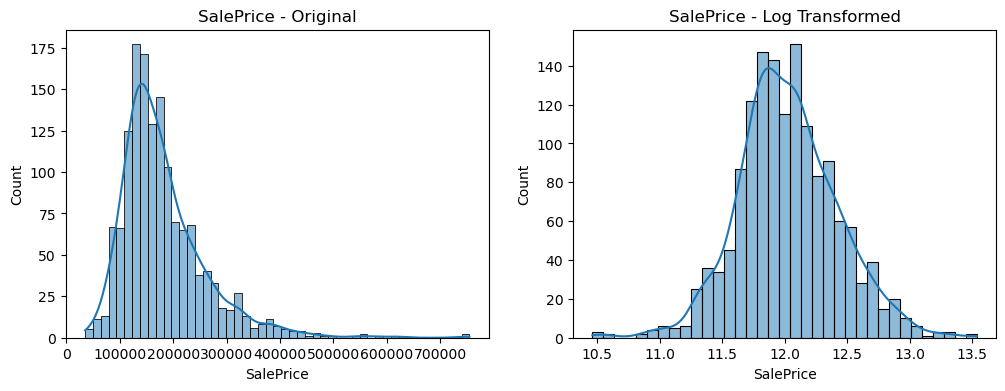

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], ax=ax1, kde=True)
ax1.set_title('SalePrice - Original')
sns.histplot(np.log1p(df['SalePrice']), ax=ax2, kde=True)
ax2.set_title('SalePrice - Log Transformed')
plt.savefig('saleprice_distribution.png', bbox_inches='tight')

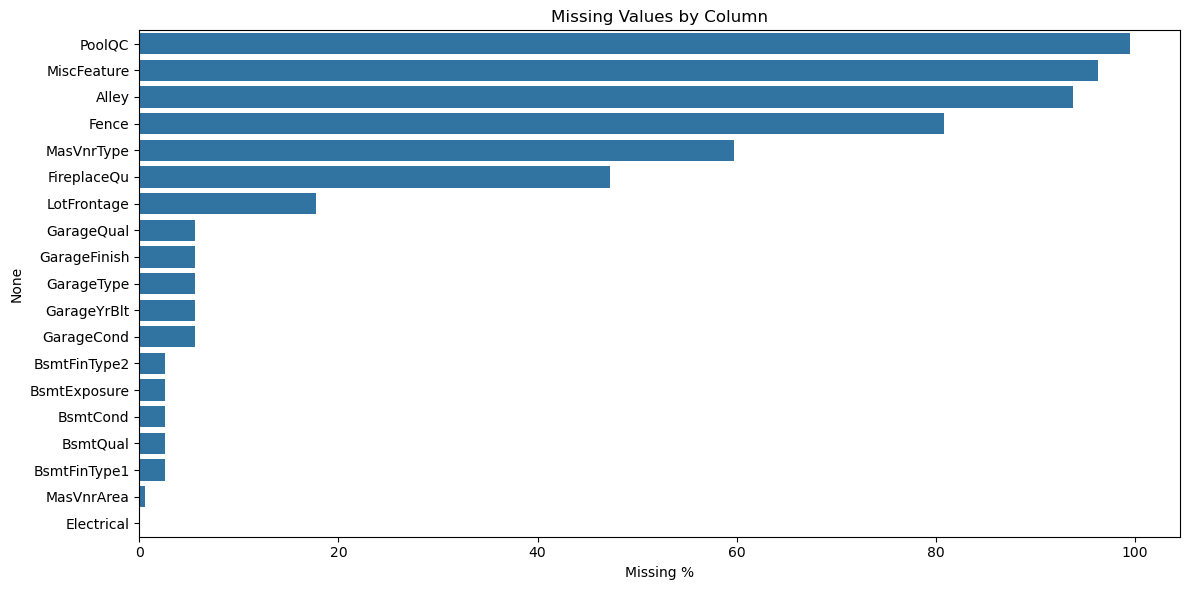

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.xlabel('Missing %')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight')
plt.show()

# Cleaning

In [65]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [66]:
df['MSSubClass'] = df['MSSubClass'].astype(str)
fill_with_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType2',
    'BsmtQual', 'BsmtCond', 'BsmtFinType1'
    ]
df[fill_with_none] = df[fill_with_none].fillna('None')

In [67]:
fill_with_0 = ['MasVnrArea']
df[fill_with_0] = df[fill_with_0].fillna(0)

In [68]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

In [69]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   str    
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          1460 non-null   str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [71]:
pd.set_option('display.max_columns', None)
df.describe()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,70.199658,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1976.507534,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,22.431902,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,26.306739,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1872.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1959.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,70.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1978.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


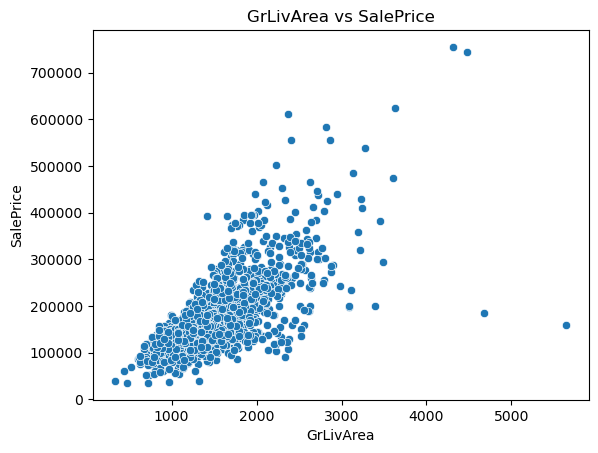

In [72]:
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice')
plt.title('GrLivArea vs SalePrice')
plt.savefig('outliers.png', bbox_inches='tight')
plt.show()

In [73]:
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)

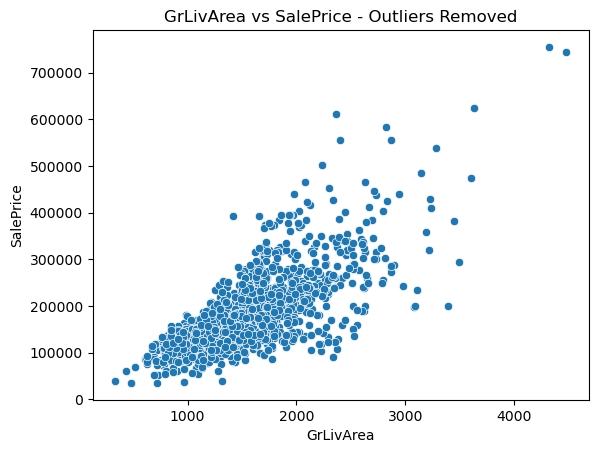

In [74]:
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice')
plt.title('GrLivArea vs SalePrice - Outliers Removed')
plt.savefig('outliers_removed.png', bbox_inches='tight')
plt.show()

# Feature Engineering

In [75]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

df['WasRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

df['TotalBath'] = (df['FullBath'] + df['HalfBath'] * 0.5 + 
                   df['BsmtFullBath'] + df['BsmtHalfBath'] * 0.5)

df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)

In [76]:
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
             'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']
for col in qual_cols:
    df[col] = df[col].map(qual_map)

bsmt_exp_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_exp_map)

garage_fin_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
df['GarageFinish'] = df['GarageFinish'].map(garage_fin_map)

functional_map = {'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7}
df['Functional'] = df['Functional'].map(functional_map)

In [77]:
from scipy.stats import skew

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns#.drop('SalePrice')
skewed = df[numeric_cols].apply(lambda x: skew(x.dropna()))
skewed = skewed[skewed > 0.75].index
df[skewed] = np.log1p(df[skewed])

In [78]:
df = pd.get_dummies(df, drop_first=True)

# Feature Selection

In [79]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import mlflow
import numpy as np

X = df.drop(columns=['SalePrice', 'Id'])
y = np.log1p(df['SalePrice'])

thresholds = [None, 0.05, 0.1, 0.15, 0.2]

for threshold in thresholds:
    if threshold is None:
        X_filtered = X.copy()
        run_name = "target_corr_no_filter_baseline"
    else:
        corr = df.corr()['SalePrice'].abs()
        selected_features = corr[corr >= threshold].index.drop('SalePrice')
        X_filtered = X[selected_features]
        run_name = f"target_corr_threshold_{threshold}"
    
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("threshold", threshold if threshold is not None else "none")
        mlflow.log_param("n_features", X_filtered.shape[1])
        
        model = Ridge()
        scores = cross_val_score(model, X_filtered, y,
                                 cv=5, scoring='neg_root_mean_squared_error')
        rmse = -scores.mean()
        
        mlflow.log_metric("cv_rmse", rmse)
        print(f"Threshold: {threshold} | Features: {X_filtered.shape[1]} | RMSE: {rmse:.4f}")

Threshold: None | Features: 240 | RMSE: 0.0091
🏃 View run target_corr_no_filter_baseline at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0/runs/23b9bc8e2813459b9cdf9e62b95a2501
🧪 View experiment at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0
Threshold: 0.05 | Features: 164 | RMSE: 0.0093
🏃 View run target_corr_threshold_0.05 at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0/runs/c3be3dd4716e445faa8300bc1ba110df
🧪 View experiment at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0
Threshold: 0.1 | Features: 118 | RMSE: 0.0094
🏃 View run target_corr_threshold_0.1 at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0/runs/bc9ecf8448b24cad94bd0818770edfca
🧪 View experiment at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0
Threshold: 0.15 | Features: 86 | RMSE: 0.0099
🏃 View run target_corr_threshold_0.15 at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0/runs/1671545dd1

In [80]:
thresholds = [None, 0.80, 0.85, 0.90, 0.95]

for threshold in thresholds:
    if threshold is None:
        X_temp = X.copy()
        run_name = "feature_corr_no_filter_baseline"
    else:
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
        X_temp = X.drop(to_drop, axis=1)
        run_name = f"feature_corr_threshold_{threshold}"
    
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("threshold", threshold if threshold is not None else "none")
        mlflow.log_param("n_features", X_temp.shape[1])
        mlflow.log_param("n_dropped", 0 if threshold is None else len(to_drop))
        
        model = Ridge()
        scores = cross_val_score(model, X_temp, y,
                                 cv=5, scoring='neg_root_mean_squared_error')
        rmse = -scores.mean()
        
        mlflow.log_metric("cv_rmse", rmse)
        print(f"Threshold: {threshold} | Features: {X_temp.shape[1]} | RMSE: {rmse:.4f}")

Threshold: None | Features: 240 | RMSE: 0.0091
🏃 View run feature_corr_no_filter_baseline at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0/runs/6ebf98f4594e47bfb4e60d8b74503d3c
🧪 View experiment at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0
Threshold: 0.8 | Features: 206 | RMSE: 0.0092
🏃 View run feature_corr_threshold_0.8 at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0/runs/b16214085e474c95b6c95bc5d202199f
🧪 View experiment at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0
Threshold: 0.85 | Features: 209 | RMSE: 0.0090
🏃 View run feature_corr_threshold_0.85 at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0/runs/1f901bc56f854c56ab47b349e384f784
🧪 View experiment at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0
Threshold: 0.9 | Features: 218 | RMSE: 0.0091
🏃 View run feature_corr_threshold_0.9 at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0/runs/b1a5f73

In [81]:
X = df.drop(columns=['SalePrice', 'Id'])
y = np.log1p(df['SalePrice'])

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
X = X.drop(to_drop, axis=1)
print(f"Dropped {len(to_drop)} features: {to_drop}")

Dropped 31 features: ['FireplaceQu', 'GarageArea', 'GarageCond', 'TotalSF', 'HouseAge', 'RemodAge', 'HasGarage', 'Has2ndFloor', 'Neighborhood_Somerst', 'BldgType_2fmCon', 'BldgType_Duplex', 'HouseStyle_1.5Unf', 'HouseStyle_1Story', 'HouseStyle_SLvl', 'RoofStyle_Hip', 'Exterior2nd_CBlock', 'Exterior2nd_CmentBd', 'Exterior2nd_HdBoard', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'Exterior2nd_Wd Sdng', 'MasVnrType_None', 'BsmtFinType1_None', 'BsmtFinType1_Unf', 'BsmtFinType2_None', 'BsmtFinType2_Unf', 'GarageType_None', 'PoolQC_None', 'MiscFeature_None', 'MiscFeature_Shed', 'SaleCondition_Partial']


In [82]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
import mlflow

kfold = KFold(n_splits=5, shuffle=True, random_state=0)

with mlflow.start_run(run_name="rfecv_feature_selection"):
    rfecv = RFECV(Ridge(), cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)
    rfecv.fit(X, y)
    
    n_before = X.shape[1]
    mlflow.log_param("n_features_selected", rfecv.n_features_)
    mlflow.log_param("n_features_before", n_before)
    mlflow.log_metric("cv_rmse", -rfecv.cv_results_['mean_test_score'].max())
    
    X = X.loc[:, rfecv.support_]
    print(f"Selected {rfecv.n_features_} features out of {n_before}")

Selected 207 features out of 209
🏃 View run rfecv_feature_selection at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0/runs/0515b8b1b16544258a808cd13d6d87d7
🧪 View experiment at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0


# Train

In [83]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (1166, 207)
Test size:  (292, 207)


In [84]:
X_train.describe()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageYrBlt,GarageFinish,GarageCars,GarageQual,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,WasRemodeled,TotalBath
count,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000
mean,4.218347,9.112055,6.084906,5.580617,1970.444254,1984.520583,2.028391,1.470579,1.402482,3.488851,2.939108,0.882737,4.159104,0.649563,5.691563,4.126930,7.002670,2.956830,0.105729,7.271782,0.409091,0.039336,1.560892,0.387650,2.888508,0.710781,3.497427,6.538593,6.831046,0.612350,1975.957976,1.710120,1.759863,2.807890,2.412012,2.291373,0.706922,0.067860,0.422781,0.021991,0.261970,6.343053,2007.830189,0.483705,2.192539
std,0.316427,0.508168,1.349803,1.117908,30.608898,20.711196,2.592795,0.123783,0.083979,0.867810,0.551764,0.357535,3.010072,1.838609,1.805201,0.961586,0.311969,3.300450,0.768690,0.322354,0.512390,0.162803,0.545899,0.501313,0.782593,0.088548,0.658710,1.569496,0.698076,0.650376,26.366563,0.886726,0.738146,0.711021,2.590637,2.156797,1.747649,0.596391,1.424297,0.375071,1.289083,2.700942,1.338238,0.499949,0.774056
min,3.091042,7.298445,1.000000,1.000000,1872.000000,1950.000000,0.000000,1.098612,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5.814131,0.000000,0.000000,5.814131,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,1.000000,0.000000,1872.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,0.000000,1.000000
25%,4.110874,8.934719,5.000000,5.000000,1953.000000,1966.000000,0.000000,1.386294,1.386294,3.000000,3.000000,0.693147,0.000000,0.000000,5.505332,3.000000,6.774509,0.000000,0.000000,7.039660,0.000000,0.000000,1.000000,0.000000,2.000000,0.693147,3.000000,5.000000,7.000000,0.000000,1959.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,0.000000,1.500000
50%,4.262680,9.156518,6.000000,5.000000,1972.000000,1993.000000,0.000000,1.386294,1.386294,4.000000,3.000000,0.693147,5.917548,0.000000,6.188262,4.000000,6.984716,0.000000,0.000000,7.293698,0.000000,0.000000,2.000000,0.000000,3.000000,0.693147,3.000000,6.000000,7.000000,1.000000,1977.000000,2.000000,2.000000,3.000000,0.000000,3.218876,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,0.000000,2.000000
75%,4.394449,9.350189,7.000000,6.000000,2000.000000,2004.000000,5.003946,1.609438,1.386294,4.000000,3.000000,1.098612,6.554645,0.000000,6.695799,5.000000,7.232552,6.594071,0.000000,7.483947,1.000000,0.000000,2.000000,1.000000,3.000000,0.693147,4.000000,7.000000,7.000000,1.000000,2001.000000,2.000000,2.000000,3.000000,5.129899,4.234107,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,1.000000,2.500000
max,5.749393,12.279537,10.000000,9.000000,2010.000000,2010.000000,7.378384,1.791759,1.791759,5.000000,4.000000,1.609438,7.691200,7.296413,7.624131,5.000000,8.079928,7.633370,6.350886,8.406708,3.000000,1.098612,3.000000,2.000000,6.000000,1.386294,5.000000,12.000000,7.000000,3.000000,2010.000000,3.000000,4.000000,5.000000,6.602588,6.306275,6.315358,6.232448,6.175867,6.605298,9.648660,12.000000,2010.000000,1.000000,6.000000


In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

with mlflow.start_run(run_name="linear_regression"):
    model = LinearRegression()
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='neg_root_mean_squared_error')
    cv_rmse = -scores.mean()
    
    model.fit(X_train, y_train)
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    
    mlflow.log_metric("cv_rmse", cv_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.sklearn.log_model(model, "model")
    print(f"CV RMSE: {cv_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

2026/04/18 14:15:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 14:15:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


CV RMSE: 0.0099 | Test RMSE: 0.0087
🏃 View run linear_regression at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0/runs/625d737a60d0452482ebb33a1ea6d316
🧪 View experiment at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0


In [86]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

with mlflow.start_run(run_name="random_forest"):
    grid = GridSearchCV(RandomForestRegressor(random_state=0),
                        param_grid, cv=5,
                        scoring='neg_root_mean_squared_error',
                        n_jobs=-1)
    grid.fit(X_train, y_train)
    test_rmse = np.sqrt(mean_squared_error(y_test, grid.predict(X_test)))
    
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("cv_rmse", -grid.best_score_)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.sklearn.log_model(grid.best_estimator_, "model")
    print(f"Best params: {grid.best_params_}")
    print(f"CV RMSE: {-grid.best_score_:.4f} | Test RMSE: {test_rmse:.4f}")

2026/04/18 14:17:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 14:17:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
CV RMSE: 0.0112 | Test RMSE: 0.0092
🏃 View run random_forest at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0/runs/bc11984307bd4e4ab031bab5e89277a8
🧪 View experiment at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0


In [87]:
from xgboost import XGBRegressor

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

with mlflow.start_run(run_name="xgboost_final5") as run:
    grid = GridSearchCV(XGBRegressor(random_state=0),
                        param_grid, cv=5,
                        scoring='neg_root_mean_squared_error',
                        n_jobs=-1)
    grid.fit(X_train, y_train)
    
    print(f"y_train mean: {y_train.mean():.4f}")
    
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("cv_rmse", -grid.best_score_)
    mlflow.sklearn.log_model(
        grid.best_estimator_,
        name="house-prices-xgboost-final",
        registered_model_name="house-prices-xgboost-final"
    )
    print(f"Run ID: {run.info.run_id}")

y_train mean: 2.5660


2026/04/18 14:18:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'house-prices-xgboost-final' already exists. Creating a new version of this model...
2026/04/18 14:18:57 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: house-prices-xgboost-final, version 5
Created version '5' of model 'house-prices-xgboost-final'.


Run ID: 92138e537624409ab22d4a67bd241dcb
🏃 View run xgboost_final5 at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0/runs/92138e537624409ab22d4a67bd241dcb
🧪 View experiment at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0


In [88]:
from sklearn.linear_model import Ridge

param_grid = {
    'alpha': [0.1, 1, 10, 50, 100]
}

with mlflow.start_run(run_name="ridge"):
    grid = GridSearchCV(Ridge(),
                        param_grid, cv=5,
                        scoring='neg_root_mean_squared_error',
                        n_jobs=-1)
    grid.fit(X_train, y_train)
    test_rmse = np.sqrt(mean_squared_error(y_test, grid.predict(X_test)))
    
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("cv_rmse", -grid.best_score_)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.sklearn.log_model(grid.best_estimator_, "model")
    print(f"Best params: {grid.best_params_}")
    print(f"CV RMSE: {-grid.best_score_:.4f} | Test RMSE: {test_rmse:.4f}")

2026/04/18 14:19:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 14:19:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params: {'alpha': 10}
CV RMSE: 0.0092 | Test RMSE: 0.0086
🏃 View run ridge at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0/runs/94db6295df7b4875b2afbee3acd0c48e
🧪 View experiment at: https://dagshub.com/lbegi23/House-Prices.mlflow/#/experiments/0
